<a href="https://colab.research.google.com/github/dangbenzy/Projects/blob/main/Bottle_sorting_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torchinfo

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import time
import numpy as np
import random
import warnings
import os
from tqdm import tqdm

import pandas as pd

import kagglehub

%matplotlib inline
warnings.filterwarnings("ignore")

In [ ]:
#Set seed for reproducibilty
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
       torch.cuda.manual_seed(seed)
       torch.cuda.manual_seed_all(seed)
       torch.backends.cudnn.deterministic = True
       torch.backends.cudnn.benchmark = True

set_seed(42)

In [50]:
# Download latest version
path = '/content/drive/MyDrive/data/archive'
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /content/drive/MyDrive/data/archive
['val_images', 'test_images']


In [76]:
@dataclass(frozen=True)
class TrainingConfig:
      ''' Configuration for Training '''
      batch_size: int = 32
      num_epochs: int = 10
      learning_rate: float = 1e-4

      log_interval: int = 1
      test_interval: int = 1
      data_root: int = "./"
      num_workers: int = 5
      device: str = "cuda"

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print("Available Device: ", DEVICE)

Available Device:  cpu


In [77]:
train_root = os.path.join("path", "train_images")
val_root = os.path.join("path", "val_images")

In [78]:

# Correctly define train_root and test_root based on the 'path' variable
# 'path' was defined in cell nnBca7tBSOIW as '/kaggle/input/pepsi-cocacola-images'
train_root = os.path.join(path, "train_images")
val_root= os.path.join(path, "val_images")

def count_images_in_directory(directory_path):
    count = 0
    if not os.path.exists(directory_path):
        print(f"Warning: Directory not found: {directory_path}")
        return 0
    for root, _, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                count += 1
    return count

train_image_count = count_images_in_directory(train_root)
val_image_count = count_images_in_directory(val_root)
data = {'Dataset': ['train_images', 'val_images'],
        'Number of Images': [train_image_count, val_image_count]}
df = pd.DataFrame(data)
print(df.to_markdown(index=False))
print(train_root)

| Dataset      |   Number of Images |
|:-------------|-------------------:|
| train_images |                470 |
| val_images   |                115 |
/content/drive/MyDrive/data/archive/train_images


In [79]:
#get mean and std
def get_mean_std(train_loader, img_size=(224, 224), num_workers=2):

     batch_mean = torch.zeros(3)
     batch_mean_sqrd = torch.zeros(3)

     for batch_data, _ in train_loader:
         batch_mean += batch_data.mean(dim=(0, 2, 3))  # E[batch_i]
         batch_mean_sqrd += (batch_data**2).mean(dim=(0, 2, 3))  #  E[batch_i**2]

     mean = batch_mean / len(train_loader)

     var = (batch_mean_sqrd / len(train_loader)) - (mean**2)

     std = var**0.5
     print("mean: {}, std: {}".format(mean, std))

     return mean, std

train_data_mean_calc = datasets.ImageFolder(root=train_root, transform = preprocess)
train_loader_mean_calc = DataLoader(train_data_mean_calc, shuffle = True, batch_size = train_config.batch_size, num_workers = train_config.num_workers)
mean, std = get_mean_std(train_loader_mean_calc)

print("Mean of Dataset: ", mean)
print("Std of Dataset: ", std)

mean: tensor([0.6278, 0.5722, 0.5747]), std: tensor([0.3357, 0.3433, 0.3446])
Mean of Dataset:  tensor([0.6278, 0.5722, 0.5747])
Std of Dataset:  tensor([0.3357, 0.3433, 0.3446])


In [57]:
#resize image and transform image to tensor

img_size = (224,224)

preprocess = transforms.Compose(
    [
        transforms.Resize(img_size, antialias=True),
        transforms.ToTensor()
    ]
)

common_transforms = transforms.Compose(
    [
        preprocess,
        transforms.Normalize(mean=mean,std=std)
    ]
)

train_transforms = transforms.Compose(
    [
        preprocess,
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([
        transforms.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75)),
         ], p =0.1),

        transforms.Normalize(mean = mean,std = std)
    ]
)

In [80]:
# Data loader, apply transforms
#Apply augmentations to the training dataset
train_data = datasets.ImageFolder(root = train_root, transform = train_transforms)

# The validation dataset should have only common transforms like Resize, ToTensor and Normalize.
val_data = datasets.ImageFolder(root=val_root, transform = common_transforms)
train_data.class_to_idx

train_loader = DataLoader(
    train_data,
    shuffle = True,
    batch_size = train_config.batch_size,
    num_workers = train_config.num_workers
)
val_loader = DataLoader(
    val_data,
    shuffle = False,
    batch_size = train_config.batch_size,
    num_workers = train_config.num_workers
)

In [59]:
class_mapping = {0:'coke', 1: 'pepsi'}

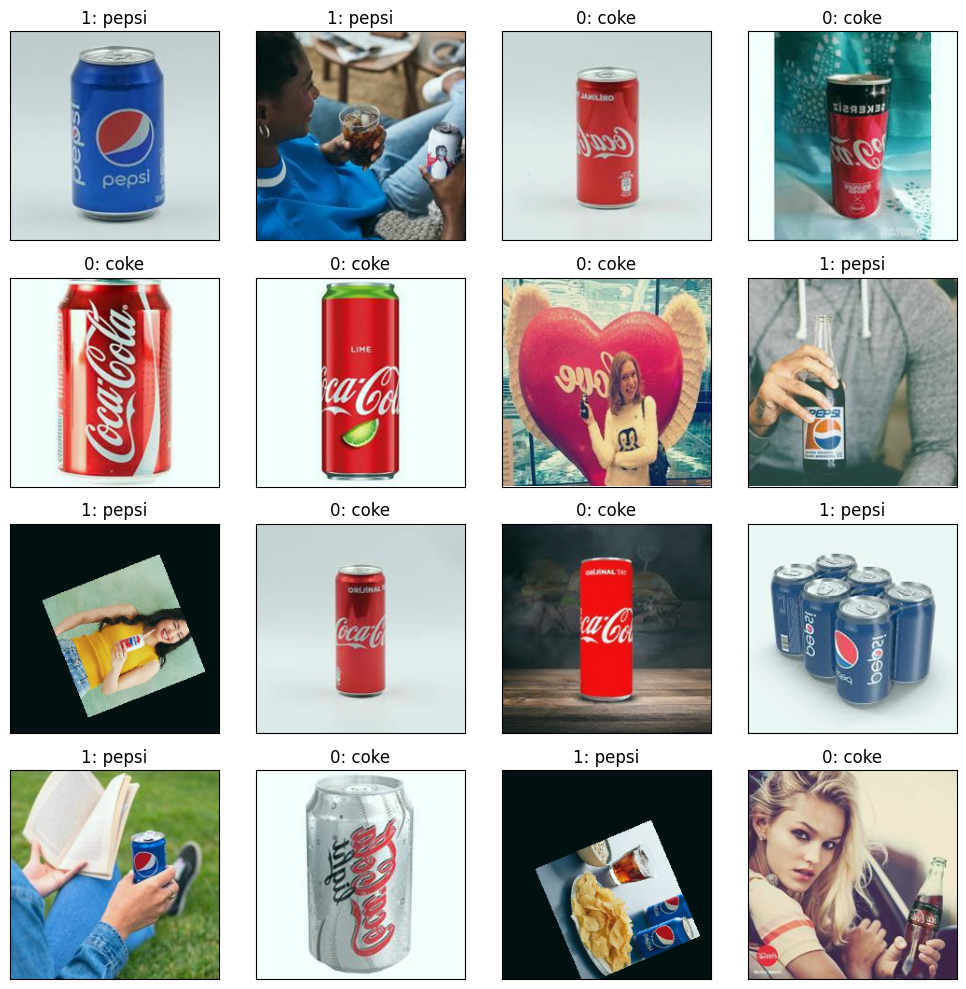

In [60]:
def visualize_images(dataloader, num_images = 20):
    fig = plt.figure(figsize=(10,10))

    #Iterate over the first batch
    images, labels = next(iter(dataloader))
    # print(images.shape)

    num_rows = 4
    num_cols = int(np.ceil((num_images / num_rows)))

    for idx in range(min(num_images, len(images))):
        image, label = images[idx], labels[idx]


        ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks = [], yticks = [])

        image = image.permute(1,2,0)

        #Normalize the image to [0,1] to display

        image = (image - image.min()) / (image.max() - image.min())
        ax.imshow(image, cmap="gray")  # remove the batch dimension
        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")

    fig.tight_layout()
    plt.show()

visualize_images(train_loader, num_images = 16)

In [81]:
# CNN Layers
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self._model = nn.Sequential(

        #---------------------- Convolution Layers ----------------------
        nn.LazyConv2d(out_channels = 32, kernel_size = 5),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace = True),

        nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2),

        nn.LazyConv2d(out_channels = 64, kernel_size = 3),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2),

        Conv2dNormActivation(in_channels = 64, out_channels=128, kernel_size = 3),
        nn.MaxPool2d(kernel_size = 2),

        Conv2dNormActivation(in_channels = 128, out_channels=256, kernel_size = 3),
        nn.MaxPool2d(kernel_size = 2),

        nn.AdaptiveAvgPool2d(output_size=(3,3)),

       # Flatten Layer
        nn.Flatten(),

       # Classification Layer
        nn.Linear(in_features = 256*3*3, out_features = 128),
        nn.Linear(in_features = 128, out_features = 2)
    )

  def forward(self,x):
      return self._model(x)

In [82]:
model = MyModel()

optimizer  = Adam(model.parameters(), lr = train_config.learning_rate)
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"

logdir = "runs/80epochs-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,224,224)
print(summary(model, dummy_input, row_settings = ["var_names"],device="cpu"))

Layer (type (var_name))                  Output Shape              Param #
MyModel (MyModel)                        [1, 2]                    --
├─Sequential (_model)                    [1, 2]                    --
│    └─Conv2d (0)                        [1, 32, 220, 220]         2,432
│    └─BatchNorm2d (1)                   [1, 32, 220, 220]         64
│    └─ReLU (2)                          [1, 32, 220, 220]         --
│    └─Conv2d (3)                        [1, 32, 218, 218]         9,248
│    └─BatchNorm2d (4)                   [1, 32, 218, 218]         64
│    └─ReLU (5)                          [1, 32, 218, 218]         --
│    └─MaxPool2d (6)                     [1, 32, 109, 109]         --
│    └─Conv2d (7)                        [1, 64, 107, 107]         18,496
│    └─BatchNorm2d (8)                   [1, 64, 107, 107]         128
│    └─ReLU (9)                          [1, 64, 107, 107]         --
│    └─MaxPool2d (10)                    [1, 64, 53, 53]           --
│   

In [83]:
#Model and Training
def train(model, train_loader):
    model.train()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_train_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_train_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    train_avg_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_predictions / total_train_samples
    return train_avg_loss, train_accuracy

In [84]:
def validation(model, val_loader):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_val_samples = 0

    for images, labels in tqdm(val_loader, desc="Validation"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
             outputs = model(images)

        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_val_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    val_avg_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct_predictions / total_val_samples
    return val_avg_loss, val_accuracy

In [85]:
def main(model, train_loader, val_loader):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model, train_loader)
        val_loss, val_accuracy = validation(model, val_loader)


        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{train_config.num_epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Logging metrics to tensorboard
        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_weights =  model.state_dict()
            print(f"Saving best model...💾")
            torch.save(best_weights, "best.pt")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [86]:
train_losses, train_accuracies, val_losses, val_accuracies = main(model, train_loader, val_loader)

Validation: 100%|██████████| 2/2 [00:14<00:00,  7.11s/it]


Epoch 01/10 - Train Loss: 0.5577, Train Accuracy: 69.79% - Val Loss: 0.7119, Val Accuracy: 50.43%
Saving best model...💾


Validation: 100%|██████████| 2/2 [00:13<00:00,  6.96s/it]


Epoch 02/10 - Train Loss: 0.4036, Train Accuracy: 85.53% - Val Loss: 0.6454, Val Accuracy: 53.91%
Saving best model...💾


Validation: 100%|██████████| 2/2 [00:13<00:00,  6.67s/it]


...

Epoch 08/10 - Train Loss: 0.2001, Train Accuracy: 92.77% - Val Loss: 0.1440, Val Accuracy: 94.78%


Validation: 100%|██████████| 2/2 [00:13<00:00,  6.84s/it]


Epoch 09/10 - Train Loss: 0.1888, Train Accuracy: 93.62% - Val Loss: 0.1286, Val Accuracy: 95.65%
Saving best model...💾


Validation: 100%|██████████| 2/2 [00:13<00:00,  6.76s/it]

Epoch 10/10 - Train Loss: 0.1541, Train Accuracy: 93.83% - Val Loss: 0.1070, Val Accuracy: 97.39%
Saving best model...💾


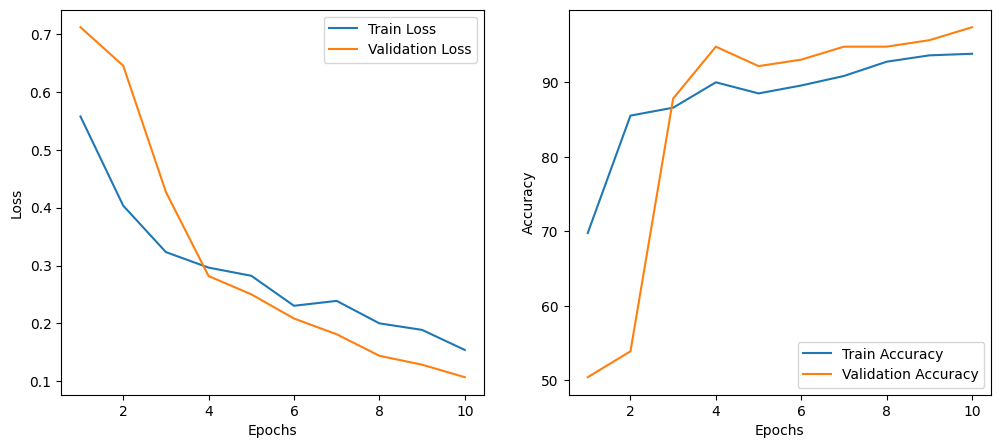

In [87]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,train_config.num_epochs + 1), train_losses, label = "Train Loss")
plt.plot(range(1, train_config.num_epochs + 1), val_losses, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,train_config.num_epochs + 1), train_accuracies, label = "Train Accuracy")
plt.plot(range(1, train_config.num_epochs + 1), val_accuracies, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [88]:
# Inference
def prediction(model, val_loader):

    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())

In [89]:
def denormalize(image):
    mean_ar = np.array(mean)
    std_ar = np.array(std)
    image = image * std_ar + mean_ar
    return np.clip(image, 0,1)

In [90]:
def visualise_predictions(sample_images,sample_gt_labels, pred_indices, pred_probs, num_images =5):

    fig = plt.figure(figsize = (20,5))

    for i in range(num_images):
        idx = random.randint(0, len(sample_images) -1)
        image = sample_images[idx].transpose(1,2,0) #(C,H,W) --> (H,W,C)
        label = sample_gt_labels[idx]
        pred_idx = pred_indices[idx]
        pred_prob = pred_probs[idx]

        image = denormalize(image)

        ax = fig.add_subplot(1, num_images, i+1)
        ax.imshow(image)
        ax.set_title(f"GT: {class_mapping[label]}\nPred: {class_mapping[pred_idx]} ({pred_prob:.2f})")
        ax.axis('off')

    plt.show()

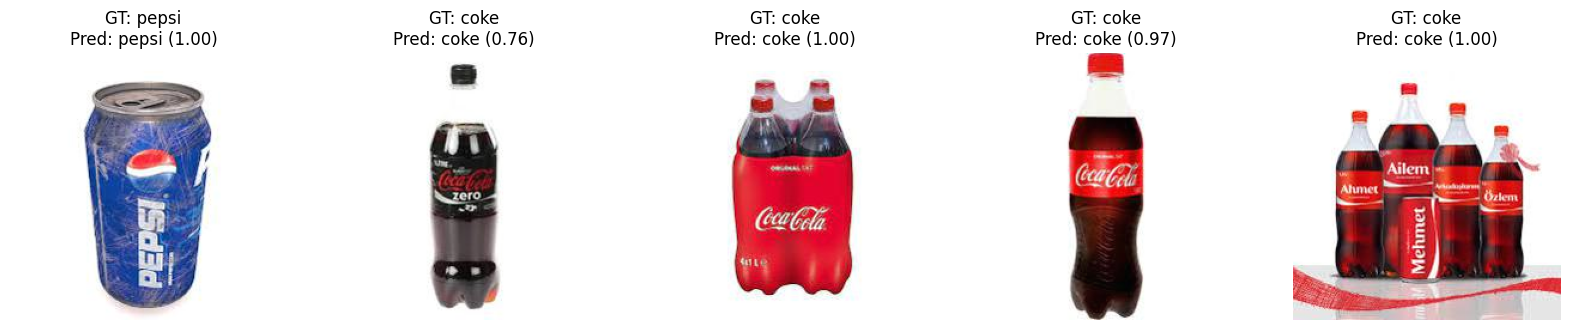

In [94]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

visualise_predictions(val_images, val_gt_labels, pred_indices, pred_probs, num_images = 5)

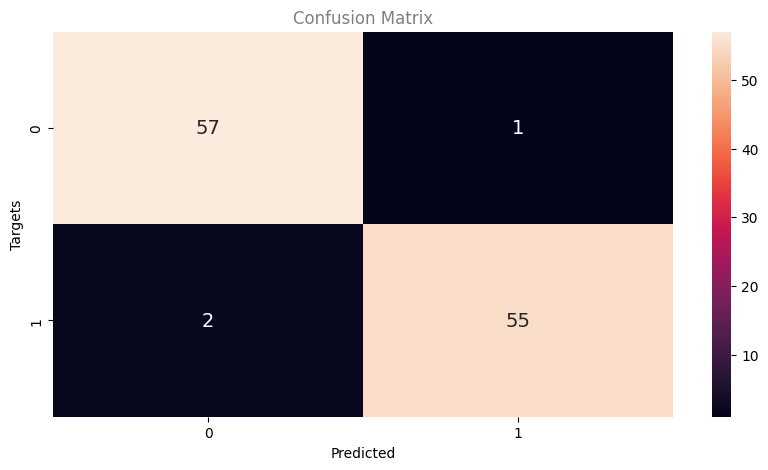

In [95]:
# Confusion Matrix
cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

plt.figure(figsize= [10,5])
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted")
plt.ylabel("Targets")
plt.title(f"Confusion Matrix", color="gray")
plt.show()